In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('t4.csv', sep=';')
df.columns = df.columns.str.strip().str.replace('"', '')
df['storeNum'] = df['storeNum'].astype(str).str.replace('"', '').astype(int)

df['treated'] = (df['storeNum'] == 109).astype(int)
df['post'] = (df['Weekind'] >= 78).astype(int)
df['treat_post'] = df['treated'] * df['post']

print("Shape:", df.shape)
print("Stores:", sorted(df["storeNum"].unique()))
print("Weeks:", df["Weekind"].min(), "to", df["Weekind"].max())
print("Treatment store 109, post period: weekind >= 78")

Shape: (2184, 18)
Stores: [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(112), np.int64(113), np.int64(114), np.int64(115), np.int64(116), np.int64(117), np.int64(118), np.int64(119), np.int64(120), np.int64(121)]
Weeks: 1 to 104
Treatment store 109, post period: weekind >= 78


In [4]:
for prod in ['p1sales', 'p2sales']: 
    print(f'\n-- {prod} --')
    table = df.groupby(['treated', 'post'])[prod].agg(['mean', 'std', 'count'])
    table.index = table.index.set_names(['Treated', 'Post'])
    print(table.round(2))


-- p1sales --
                mean    std  count
Treated Post                      
0       0     383.05  69.16   1540
        1     387.32  82.97    540
1       0     324.36  14.40     77
        1     360.85  17.05     27

-- p2sales --
                mean     std  count
Treated Post                       
0       0     463.18  112.56   1540
        1     467.91  122.22    540
1       0     380.49   28.59     77
        1     362.96   38.01     27


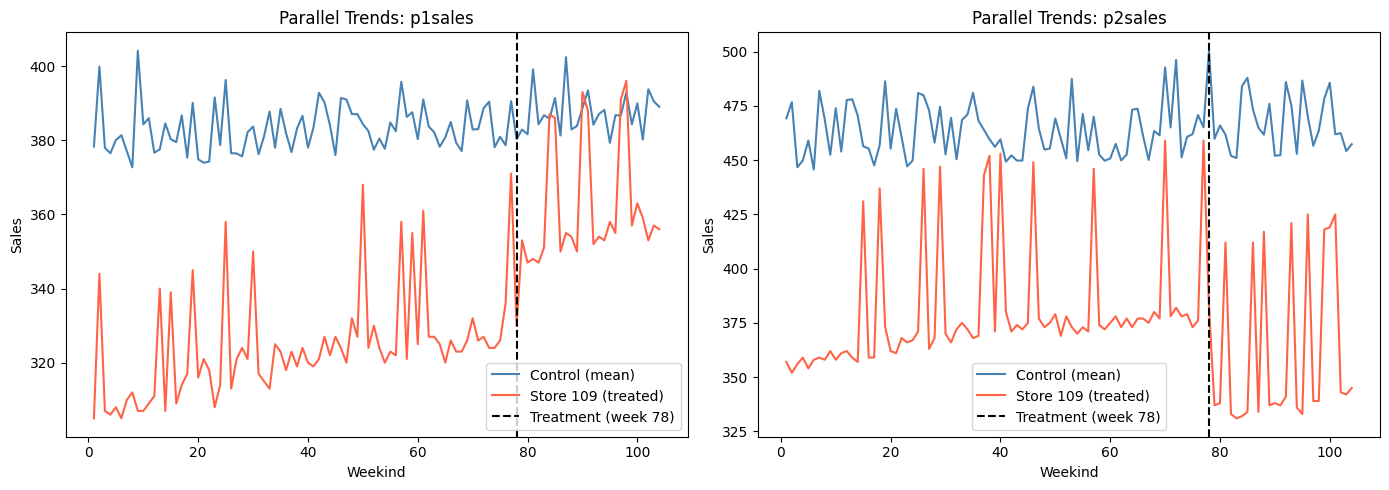


Parallel trends plot saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, prod in enumerate(["p1sales", "p2sales"]):
    treated_ts = df[df["treated"] == 1].groupby("Weekind")[prod].mean()
    control_ts = df[df["treated"] == 0].groupby("Weekind")[prod].mean()
    
    axes[i].plot(control_ts.index, control_ts.values, label="Control (mean)", color="steelblue")
    axes[i].plot(treated_ts.index, treated_ts.values, label="Store 109 (treated)", color="tomato")
    axes[i].axvline(x=78, color="black", linestyle="--", label="Treatment (week 78)")
    axes[i].set_title(f"Parallel Trends: {prod}")
    axes[i].set_xlabel("Weekind")
    axes[i].set_ylabel("Sales")
    axes[i].legend()
plt.tight_layout()

plt.show()
print("\nParallel trends plot saved.")


In [6]:
import statsmodels.formula.api as smf

store109 = df[df['treated'] == 1].copy()

for prod in ['p1sales', 'p2sales']: 
    formula = f'{prod} ~ post + {prod.replace("sales", "price")} + {prod.replace("sales", "prom")} + compind'
    model = smf.ols(formula, data=store109).fit(cov_type='HC1')
    print(f'{prod}\nFormula: {formula}')
    print(f'{model.summary2().tables[1]}')
    print(f'\nPre-post treatment effect estimate: {model.params["post"]:.2f} (p={model.pvalues["post"]:.4f})')

p1sales
Formula: p1sales ~ post + p1price + p1prom + compind
                Coef.  Std.Err.          z          P>|z|      [0.025  \
Intercept  282.676750  5.631702  50.193843   0.000000e+00  271.638817   
post        33.689387  1.544682  21.809924  1.867844e-105   30.661867   
p1price     -0.470422  2.408546  -0.195313   8.451476e-01   -5.191086   
p1prom      35.286051  2.354490  14.986706   8.969257e-51   30.671335   
compind    103.459690  2.061203  50.193843   0.000000e+00   99.419807   

               0.975]  
Intercept  293.714682  
post        36.716907  
p1price      4.250243  
p1prom      39.900766  
compind    107.499574  

Pre-post treatment effect estimate: 33.69 (p=0.0000)
p2sales
Formula: p2sales ~ post + p2price + p2prom + compind
                Coef.  Std.Err.          z         P>|z|      [0.025  \
Intercept  335.448499  5.845090  57.389790  0.000000e+00  323.992332   
post       -29.710065  2.104538 -14.117145  2.978156e-45  -33.834883   
p2price     -4.068014  2.

In [7]:
for prod in ['p1sales', 'p2sales']:
    price = prod.replace('sales', 'price')
    prom = prod.replace('sales', 'prom')

    formula = f'{prod} ~ treat_post + {price} + {prom} + C(storeNum) + C(Weekind)'
    model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups' : df['storeNum']})
    print(f'\n-- {prod} --')
    key_vars = ['treat_post', price, prom]
    print(f'{"Variable":<15} {"Coef":>10} {"Std.Err.":>10} {"P-value":>10}')
    print('-'*40)
    for var in key_vars:
        print(f"{var:<15} {model.params[var]:>10.3f} {model.bse[var]:>10.3f} {model.pvalues[var]:>10.4f}")

    print(f"\nTWFE treatment effect: {model.params['treat_post']:.2f} (p={model.pvalues['treat_post']:.4f})")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"N = {int(model.nobs)}")



-- p1sales --
Variable              Coef   Std.Err.    P-value
----------------------------------------
treat_post          29.979      4.256     0.0000
p1price             -2.475      0.891     0.0055
p1prom              37.590      1.470     0.0000

TWFE treatment effect: 29.98 (p=0.0000)
R-squared: 0.9773
N = 2184

-- p2sales --
Variable              Coef   Std.Err.    P-value
----------------------------------------
treat_post         -34.291      4.699     0.0000
p2price             -2.951      0.861     0.0006
p2prom              89.424      4.538     0.0000

TWFE treatment effect: -34.29 (p=0.0000)
R-squared: 0.9870
N = 2184


In [8]:
print(f'\n -- 3a: simple 2x2 did (raw means) --')
for prod in ['p1sales', 'p2sales']: 
    means = df.groupby(['treated', 'post'])[prod].mean()

    pre_treat = means[(1, 0)]
    post_treat = means[(1, 1)]
    pre_ctrl = means[(0, 0)]
    post_ctrl = means[(0, 1)]

    did = (post_treat - pre_treat) - (post_ctrl - pre_ctrl)
    
    print(f'  {prod}:')
    print(f'    Treated:  pre={pre_treat:.2f}  post={post_treat:.2f}  diff={post_treat-pre_treat:+.2f}')
    print(f'    Control:  pre={pre_ctrl:.2f}   post={post_ctrl:.2f}   diff={post_ctrl-pre_ctrl:+.2f}')
    print(f'    DID estimate: {did:+.2f}\n')

print(f'\n -- 3b: did regression (w covariates) --')
for prod in ['p1sales', 'p2sales']:
    price = prod.replace('sales', 'price')
    prom = prod.replace('sales', 'prom')
    formula = f'{prod} ~ treated + post + treat_post + {price} + {prom} + compind + storesize + citysize'
    model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups' : df['storeNum']})
    print(f'    {prod}')
    key_vars = ['treated', 'post', 'treat_post', price, prom]
    print(f"  {'Variable':<15} {'Coef':>10} {'Std.Err':>10} {'P-value':>10}")
    print(f"  {'-'*47}")
    for var in key_vars:
        print(f"  {var:<15} {model.params[var]:>10.3f} {model.bse[var]:>10.3f} {model.pvalues[var]:>10.4f}")
    print(f"\n  DID treatment effect: {model.params['treat_post']:.2f} (p={model.pvalues['treat_post']:.4f})")
    print(f"  R-squared: {model.rsquared:.4f}, N = {int(model.nobs)}\n")



 -- 3a: simple 2x2 did (raw means) --
  p1sales:
    Treated:  pre=324.36  post=360.85  diff=+36.49
    Control:  pre=383.05   post=387.32   diff=+4.27
    DID estimate: +32.22

  p2sales:
    Treated:  pre=380.49  post=362.96  diff=-17.53
    Control:  pre=463.18   post=467.91   diff=+4.73
    DID estimate: -22.26


 -- 3b: did regression (w covariates) --
    p1sales
  Variable              Coef    Std.Err    P-value
  -----------------------------------------------
  treated            -33.633      1.109     0.0000
  post                 3.538      4.066     0.3842
  treat_post          29.974      4.138     0.0000
  p1price             -2.585      0.800     0.0012
  p1prom              37.619      1.457     0.0000

  DID treatment effect: 29.97 (p=0.0000)
  R-squared: 0.9767, N = 2184

    p2sales
  Variable              Coef    Std.Err    P-value
  -----------------------------------------------
  treated            -18.371      1.136     0.0000
  post                 2.905      


p1sales

  Donor weights (non-zero):
    Store 101: 0.0500
    Store 102: 0.0500
    Store 103: 0.0500
    Store 104: 0.0500
    Store 105: 0.0500
    Store 106: 0.0500
    Store 107: 0.0500
    Store 108: 0.0500
    Store 110: 0.0500
    Store 111: 0.0500
    Store 112: 0.0500
    Store 113: 0.0500
    Store 114: 0.0500
    Store 115: 0.0500
    Store 116: 0.0500
    Store 117: 0.0500
    Store 118: 0.0500
    Store 119: 0.0500
    Store 120: 0.0500
    Store 121: 0.0500

  Pre-treatment RMSE: 60.19
  ATT (avg post-treatment effect): -26.47
  Post-period effects by week: min=-51.1, max=4.3


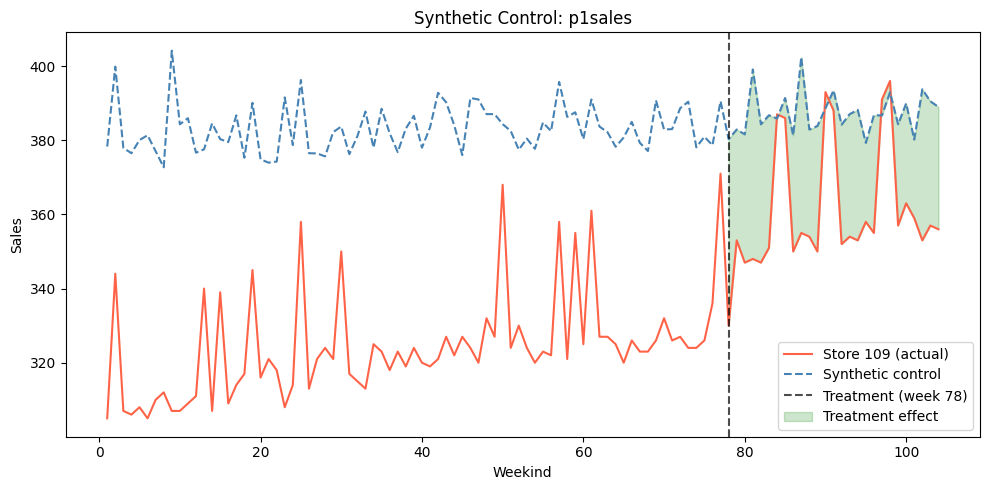


p2sales

  Donor weights (non-zero):
    Store 101: 0.0500
    Store 102: 0.0500
    Store 103: 0.0500
    Store 104: 0.0500
    Store 105: 0.0500
    Store 106: 0.0500
    Store 107: 0.0500
    Store 108: 0.0500
    Store 110: 0.0500
    Store 111: 0.0500
    Store 112: 0.0500
    Store 113: 0.0500
    Store 114: 0.0500
    Store 115: 0.0500
    Store 116: 0.0500
    Store 117: 0.0500
    Store 118: 0.0500
    Store 119: 0.0500
    Store 120: 0.0500
    Store 121: 0.0500

  Pre-treatment RMSE: 87.43
  ATT (avg post-treatment effect): -104.94
  Post-period effects by week: min=-153.9, max=-36.9


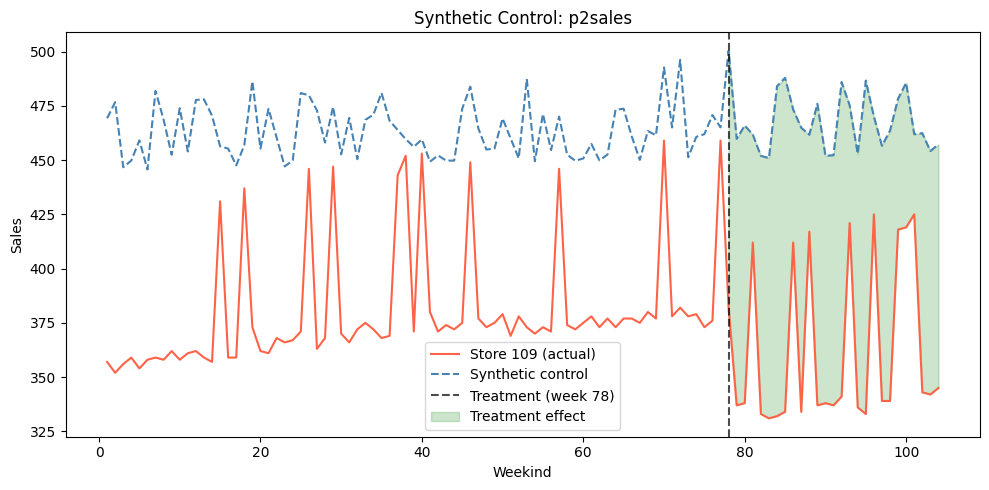

In [9]:
from scipy.optimize import minimize 

control_stores = [s for s in df['storeNum'].unique() if s != 109]
pre_periods = df[df['post'] == 0]['Weekind'].unique()
post_periods = df[df['post'] == 1]['Weekind'].unique()

for prod in ['p1sales', 'p2sales']:
    print(f'\n{"="*40}')
    print(f'{prod}')
    print(f'{"="*40}')

    pivot = df.pivot_table(index='Weekind', columns='storeNum', values=prod)
    Y_treat_pre = pivot.loc[pre_periods, 109].values
    Y_treat_post = pivot.loc[post_periods, 109].values
    Y_control_pre = pivot.loc[pre_periods, control_stores].values
    Y_control_post = pivot.loc[post_periods, control_stores].values

    n_control = len(control_stores)

    #obj func
    def objective(w): 
        synthetic_pre = Y_control_pre @ w
        return np.sum((Y_treat_pre - synthetic_pre) ** 2)

    constraints = {'type' : 'eq', 'fun' : lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n_control
    w0 = np.ones(n_control) / n_control
    result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints, options={'maxiter' : 1_000, 'ftol' : 1e-12})
    weights = result.x

    synth_pre = Y_control_pre @ weights 
    synth_post = Y_control_post @ weights 

    pre_rmse = np.sqrt(np.mean((Y_treat_pre - synth_pre) ** 2))

    effects = Y_treat_post - synth_post 
    att = np.mean(effects)
    print(f'\n  Donor weights (non-zero):')
    for i, s in enumerate(control_stores):
        if weights[i] > 0.01:
            print(f'    Store {s}: {weights[i]:.4f}')
    
    print(f'\n  Pre-treatment RMSE: {pre_rmse:.2f}')
    print(f'  ATT (avg post-treatment effect): {att:.2f}')
    print(f'  Post-period effects by week: min={effects.min():.1f}, max={effects.max():.1f}')
    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    all_periods = sorted(np.concatenate([pre_periods, post_periods]))
    actual = pivot.loc[all_periods, 109].values
    synthetic = np.concatenate([synth_pre, synth_post])
    
    ax.plot(all_periods, actual, label="Store 109 (actual)", color="tomato")
    ax.plot(all_periods, synthetic, label="Synthetic control", color="steelblue", linestyle="--")
    ax.axvline(x=78, color="black", linestyle="--", alpha=0.7, label="Treatment (week 78)")
    ax.fill_between(post_periods, Y_treat_post, synth_post, alpha=0.2, color="green", label="Treatment effect")
    ax.set_title(f"Synthetic Control: {prod}")
    ax.set_xlabel("Weekind")
    ax.set_ylabel("Sales")
    ax.legend()
    plt.tight_layout()
    # plt.savefig(f"t4_scm_{prod}.pdf")
    plt.show()




  p1sales

  Donor weights (non-zero, >1%):
    Store 110: 0.4333
    Store 111: 0.4332
    Store 113: 0.0393
    Store 114: 0.0231
    Store 118: 0.0256
    Store 119: 0.0394

  Pre-treatment RMSE: 4.05
  ATT (avg post-treatment effect): 17.66
  Post-period effects by week: min=1.3, max=23.2


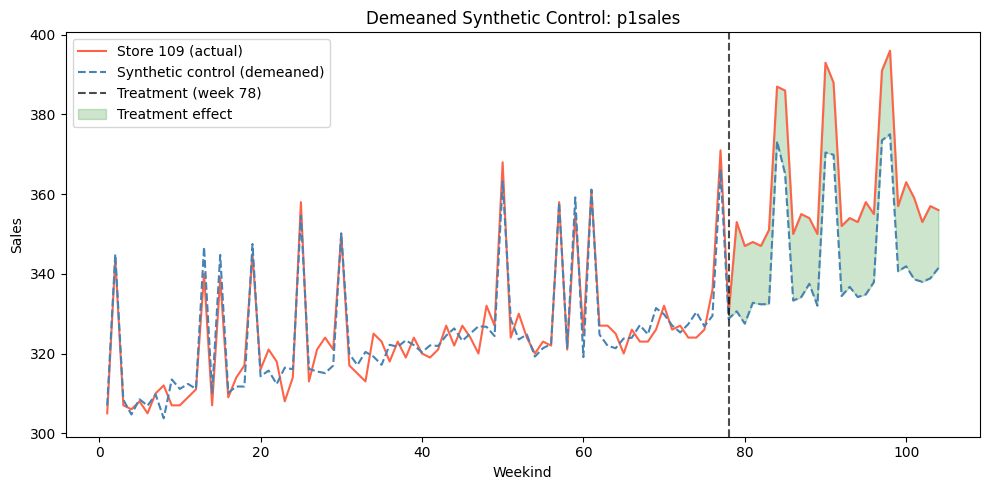


  p2sales

  Donor weights (non-zero, >1%):
    Store 103: 0.0254
    Store 105: 0.0300
    Store 110: 0.3510
    Store 111: 0.4430
    Store 114: 0.0175
    Store 117: 0.0563
    Store 119: 0.0177
    Store 120: 0.0364
    Store 121: 0.0138

  Pre-treatment RMSE: 4.13
  ATT (avg post-treatment effect): -46.00
  Post-period effects by week: min=-58.6, max=-1.5


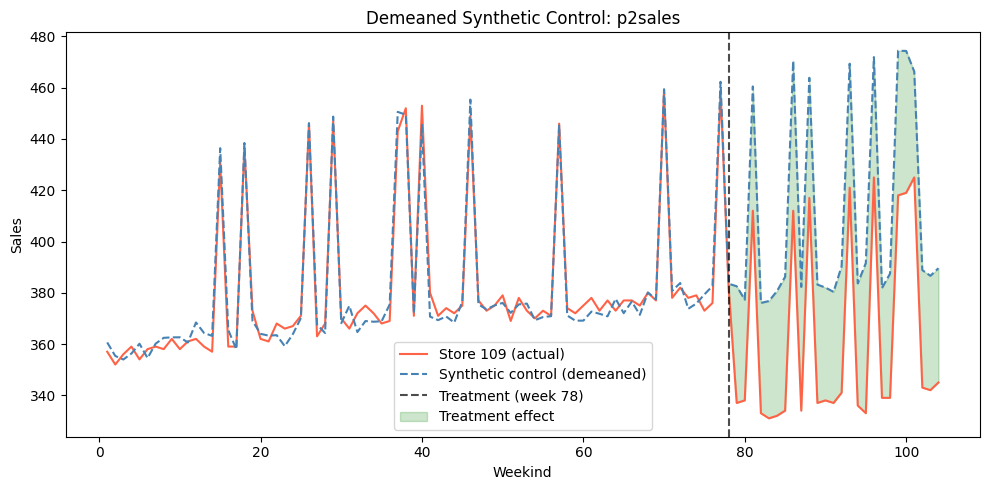

In [10]:
control_stores = [s for s in df['storeNum'].unique() if s != 109]
pre_periods = df[df['post'] == 0]['Weekind'].unique()
post_periods = df[df['post'] == 1]['Weekind'].unique()

for prod in ['p1sales', 'p2sales']:
    print(f"\n{'='*50}")
    print(f"  {prod}")
    print(f"{'='*50}")
    
    pivot = df.pivot_table(index="Weekind", columns="storeNum", values=prod)
    
    pre_means = pivot.loc[pre_periods].mean(axis=0)
    pivot_dm = pivot - pre_means  # each store now centered at 0 in pre-period
    
    Y_treat_pre = pivot_dm.loc[pre_periods, 109].values
    Y_treat_post = pivot_dm.loc[post_periods, 109].values
    Y_control_pre = pivot_dm.loc[pre_periods, control_stores].values
    Y_control_post = pivot_dm.loc[post_periods, control_stores].values
    
    n_control = len(control_stores)
    
    def objective(w):
        synthetic_pre = Y_control_pre @ w
        return np.sum((Y_treat_pre - synthetic_pre) ** 2)
    
    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0, 1)] * n_control
    w0 = np.ones(n_control) / n_control
    
    result = minimize(objective, w0, method="SLSQP", bounds=bounds, constraints=constraints,
                      options={"maxiter": 1000, "ftol": 1e-12})
    weights = result.x
    
    synth_pre_dm = Y_control_pre @ weights
    synth_post_dm = Y_control_post @ weights
    
    treated_pre_mean = pre_means[109]
    synth_pre = synth_pre_dm + treated_pre_mean
    synth_post = synth_post_dm + treated_pre_mean
    
    actual_pre = pivot.loc[pre_periods, 109].values
    actual_post = pivot.loc[post_periods, 109].values
    
    pre_rmse = np.sqrt(np.mean((actual_pre - synth_pre) ** 2))
    effects = actual_post - synth_post
    att = np.mean(effects)
    
    print(f"\n  Donor weights (non-zero, >1%):")
    for i, s in enumerate(control_stores):
        if weights[i] > 0.01:
            print(f"    Store {s}: {weights[i]:.4f}")
    
    print(f"\n  Pre-treatment RMSE: {pre_rmse:.2f}")
    print(f"  ATT (avg post-treatment effect): {att:.2f}")
    print(f"  Post-period effects by week: min={effects.min():.1f}, max={effects.max():.1f}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    all_periods = sorted(np.concatenate([pre_periods, post_periods]))
    actual_all = pivot.loc[all_periods, 109].values
    synthetic_all = np.concatenate([synth_pre, synth_post])
    
    ax.plot(all_periods, actual_all, label="Store 109 (actual)", color="tomato")
    ax.plot(all_periods, synthetic_all, label="Synthetic control (demeaned)", color="steelblue", linestyle="--")
    ax.axvline(x=78, color="black", linestyle="--", alpha=0.7, label="Treatment (week 78)")
    ax.fill_between(post_periods, actual_post, synth_post, alpha=0.2, color="green", label="Treatment effect")
    ax.set_title(f"Demeaned Synthetic Control: {prod}")
    ax.set_xlabel("Weekind")
    ax.set_ylabel("Sales")
    ax.legend()
    plt.tight_layout()
    plt.show()


p1sales
  sigma_hat: 22.81, zeta: 51.98
  omega_0: -85.68
  donor weights >1%:
    store 101: 0.0309
    store 102: 0.0309
    store 103: 0.0309
    store 104: 0.0309
    store 105: 0.0311
    store 106: 0.0309
    store 107: 0.0281
    store 108: 0.0281
    store 110: 0.0337
    store 111: 0.4667
    store 112: 0.0281
    store 113: 0.0313
    store 114: 0.0281
    store 115: 0.0281
    store 116: 0.0281
    store 117: 0.0281
    store 118: 0.0309
    store 119: 0.0309
    store 120: 0.0294
    store 121: 0.0281
  lambda_0: 1.96
  non-uniform time weights: 19 of 77
  last 10 pre-period weight: 0.3840
  delta_treated: 27.27, delta_control: 7.73
  tau: 19.54


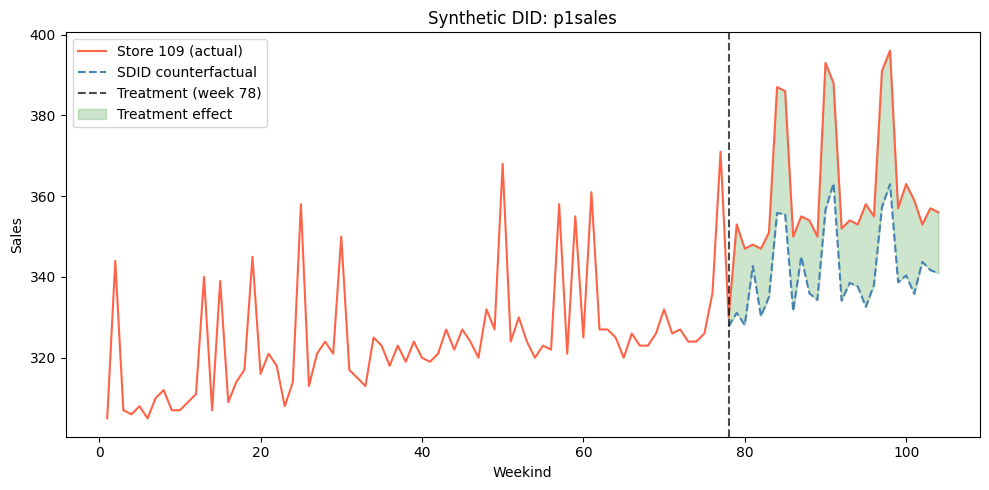


p2sales
  sigma_hat: 48.99, zeta: 111.68
  omega_0: -87.17
  donor weights >1%:
    store 101: 0.0383
    store 102: 0.0350
    store 103: 0.0429
    store 104: 0.0411
    store 105: 0.0390
    store 106: 0.0389
    store 107: 0.0334
    store 108: 0.0366
    store 110: 0.1065
    store 111: 0.1213
    store 112: 0.0444
    store 113: 0.0496
    store 114: 0.0467
    store 115: 0.0437
    store 116: 0.0429
    store 117: 0.0447
    store 118: 0.0433
    store 119: 0.0594
    store 120: 0.0546
    store 121: 0.0376
  lambda_0: 4.33
  non-uniform time weights: 4 of 77
  last 10 pre-period weight: 0.2331
  delta_treated: -29.89, delta_control: 7.00
  tau: -36.89


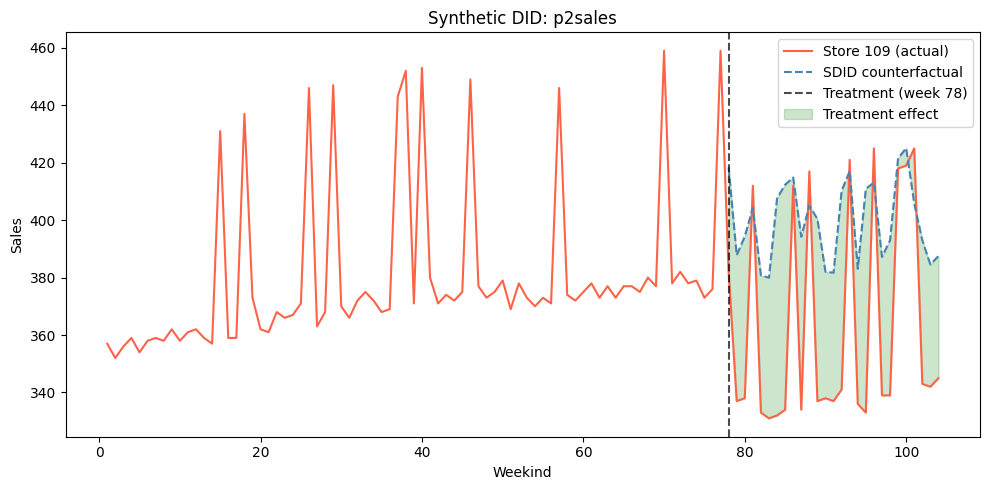

In [11]:
control_stores = [s for s in df['storeNum'].unique() if s != 109]
pre_periods = sorted(df[df['post'] == 0]['Weekind'].unique())
post_periods = sorted(df[df['post'] == 1]['Weekind'].unique())
T_pre = len(pre_periods)
T_post = len(post_periods)
N_co = len(control_stores)

for prod in ['p1sales', 'p2sales']:
    print(f'\n{prod}')

    pivot = df.pivot_table(index='Weekind', columns='storeNum', values=prod)

    Y_co_pre = pivot.loc[pre_periods, control_stores].values
    Y_co_post = pivot.loc[post_periods, control_stores].values
    Y_tr_pre = pivot.loc[pre_periods, 109].values
    Y_tr_post = pivot.loc[post_periods, 109].values

    dY = np.diff(pivot.loc[:, control_stores].values, axis=0)
    sigma_hat = np.std(dY)
    zeta = (1 * T_post) ** 0.25 * sigma_hat

    print(f'  sigma_hat: {sigma_hat:.2f}, zeta: {zeta:.2f}')

    def unit_obj(params):
        intercept = params[0]
        w = params[1:]
        resid = intercept + Y_co_pre @ w - Y_tr_pre
        return np.sum(resid**2) + zeta**2 * T_pre * np.sum(w**2)

    cons_unit = [{'type': 'eq', 'fun': lambda p: np.sum(p[1:]) - 1}]
    bounds_unit = [(None, None)] + [(0, 1)] * N_co
    p0 = np.concatenate([[0.0], np.ones(N_co) / N_co])

    res_unit = minimize(unit_obj, p0, method='SLSQP', bounds=bounds_unit,
                        constraints=cons_unit, options={'maxiter': 2000, 'ftol': 1e-14})
    omega_intercept = res_unit.x[0]
    omega = res_unit.x[1:]

    Y_co_post_mean = Y_co_post.mean(axis=0)

    def time_obj(params):
        intercept = params[0]
        lam = params[1:]
        resid = intercept + Y_co_pre.T @ lam - Y_co_post_mean
        return np.sum(resid**2) + zeta**2 * N_co * np.sum(lam**2)

    cons_time = [{'type': 'eq', 'fun': lambda p: np.sum(p[1:]) - 1}]
    bounds_time = [(None, None)] + [(0, None)] * T_pre
    p0_time = np.concatenate([[0.0], np.ones(T_pre) / T_pre])

    res_time = minimize(time_obj, p0_time, method='SLSQP', bounds=bounds_time,
                        constraints=cons_time, options={'maxiter': 2000, 'ftol': 1e-14})
    lambda_intercept = res_time.x[0]
    lam = res_time.x[1:]

    delta_treated = Y_tr_post.mean() - lam @ Y_tr_pre
    delta_control = omega @ Y_co_post.mean(axis=0) - lam @ (Y_co_pre @ omega)
    tau_sdid = delta_treated - delta_control

    print(f'  omega_0: {omega_intercept:.2f}')
    print(f'  donor weights >1%:')
    for i, s in enumerate(control_stores):
        if omega[i] > 0.01:
            print(f'    store {s}: {omega[i]:.4f}')

    print(f'  lambda_0: {lambda_intercept:.2f}')
    print(f'  non-uniform time weights: {np.sum(lam > 2.0/T_pre)} of {T_pre}')
    print(f'  last 10 pre-period weight: {lam[-10:].sum():.4f}')
    print(f'  delta_treated: {delta_treated:.2f}, delta_control: {delta_control:.2f}')
    print(f'  tau: {tau_sdid:.2f}')

    synth_post = (lam @ Y_tr_pre) + (Y_co_post @ omega - (lam @ Y_co_pre @ omega))

    fig, ax = plt.subplots(figsize=(10, 5))
    all_weeks = pre_periods + post_periods
    ax.plot(all_weeks, np.concatenate([Y_tr_pre, Y_tr_post]),
            label='Store 109 (actual)', color='tomato')
    ax.plot(post_periods, synth_post,
            label='SDID counterfactual', color='steelblue', linestyle='--')
    ax.axvline(x=78, color='black', linestyle='--', alpha=0.7, label='Treatment (week 78)')
    ax.fill_between(post_periods, Y_tr_post, synth_post, alpha=0.2, color='green',
                    label='Treatment effect')
    ax.set_title(f'Synthetic DID: {prod}')
    ax.set_xlabel('Weekind')
    ax.set_ylabel('Sales')
    ax.legend()
    plt.tight_layout()
    plt.show()

                            method  p1 effect  p2 effect
      1. pre-post (store 109 only)      33.69     -29.71
   2. twfe panel (store + time fe)      29.98     -34.29
        3a. simple did (raw means)      32.22     -22.26
3b. did regression (w/ covariates)      29.97     -34.35
                   4. demeaned scm      17.66     -46.00
                  5. synthetic did      19.54     -36.89


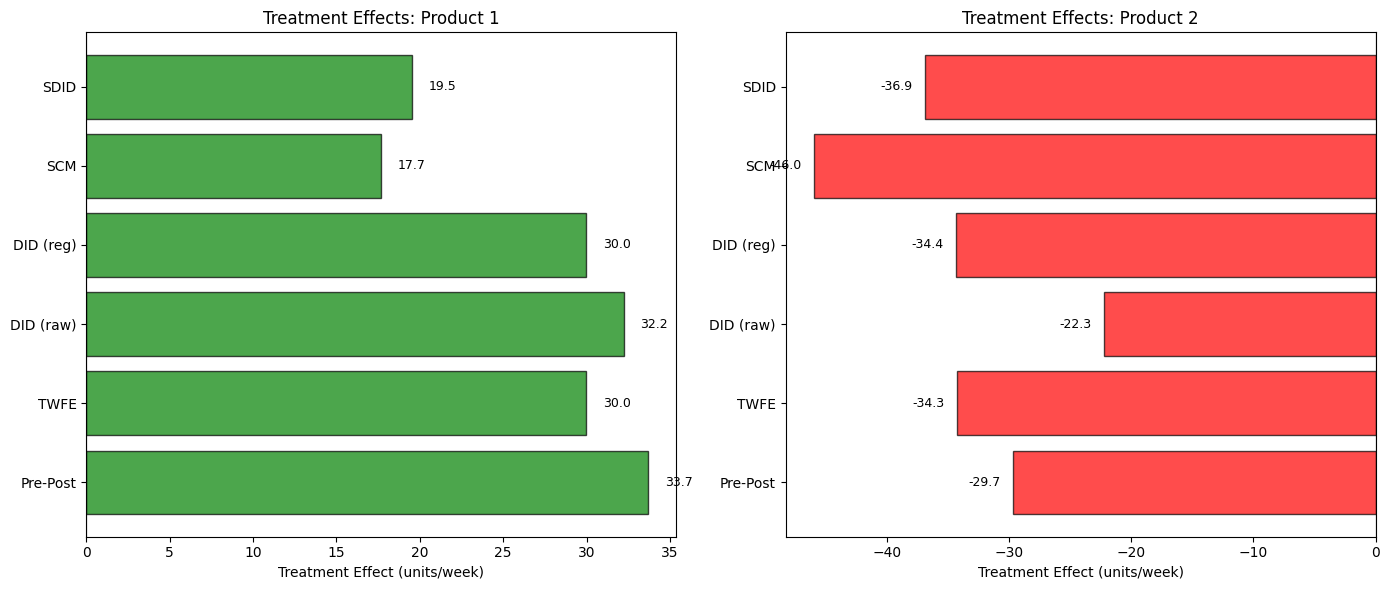

In [ ]:
results = {
    'method': [
        '1. pre-post (store 109 only)',
        '2. twfe panel (store + time fe)',
        '3a. simple did (raw means)',
        '3b. did regression (w/ covariates)',
        '4. demeaned scm',
        '5. synthetic did'
    ],
    'p1 effect': [33.69, 29.98, 32.22, 29.97, 17.66, 19.54],
    'p2 effect': [-29.71, -34.29, -22.26, -34.35, -46.00, -36.89]
}
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
methods_short = ['Pre-Post', 'TWFE', 'DID (raw)', 'DID (reg)', 'SCM', 'SDID']

for i, (prod, col) in enumerate([('Product 1', 'p1 effect'), ('Product 2', 'p2 effect')]):
    vals = results_df[col].values
    colors = ['green' if v > 0 else 'red' for v in vals]
    axes[i].barh(methods_short, vals, color=colors, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('Treatment Effect (units/week)')
    axes[i].set_title(f'Treatment Effects: {prod}')
    axes[i].axvline(x=0, color='black', linewidth=0.8)
    for j, v in enumerate(vals):
        axes[i].text(v + (1 if v > 0 else -1), j, f'{v:.1f}', va='center',
                     ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()